# Data Exploration

Phase 1–2: Explore the raw and interim data to understand structure and quality.

In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

## Load both Datasets

In [2]:
argo_df = pd.read_csv("../data/raw/argo/argo_2023-01-01_2023-02-01.csv")
sst_ds = xr.open_dataset("../data/raw/sst/sst_2023-01-01_2023-02-01.nc")

print("Argo:", argo_df.shape, argo_df["float_id"].nunique(), "floats")
print("SST:", sst_ds.dims)

Argo: (145975, 7) 228 floats
SST: FrozenMappingWarningOnValuesAccess({'time': 32, 'zlev': 1, 'lat': 100, 'lon': 240})


Cell 3 — get unique float locations (one point per float, not per depth level)

In [3]:
float_locations = argo_df.drop_duplicates(subset="float_id")[["float_id", "lat", "lon"]]
print(float_locations.shape)
float_locations.head()

(228, 3)


,float_id,lat,lon
0,2902275_240,16.551994,70.676422
1050,6903063_306,16.181878,56.123050
1650,6903062_306,12.453552,48.584823
2227,6903058_306,20.935833,59.515735
2813,6903008_306,23.815880,63.268098


Cell 4 — plot SST heatmap with Argo floats overlaid

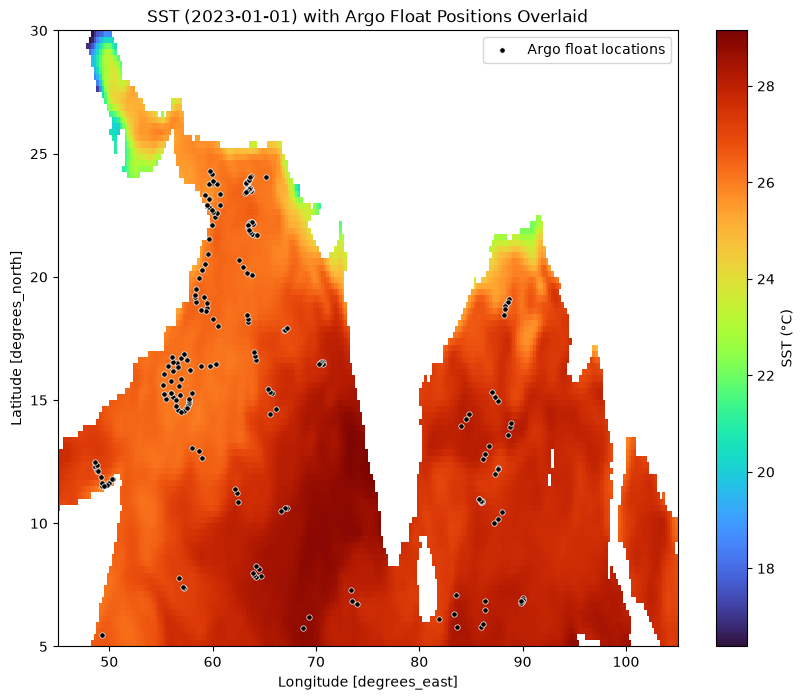

In [4]:
sst_day1 = sst_ds.sst.isel(time=0, zlev=0)

fig, ax = plt.subplots(figsize=(10, 8))
sst_day1.plot(ax=ax, cmap="turbo", cbar_kwargs={"label": "SST (°C)"})

ax.scatter(
    float_locations["lon"], float_locations["lat"],
    c="black", s=15, marker="o", edgecolors="white", linewidths=0.5,
    label="Argo float locations"
)

ax.set_title("SST (2023-01-01) with Argo Float Positions Overlaid")
ax.legend()
plt.show()